## 3. Plotting 
Two reusable functions:
- `plot_runs_all_subjects` — 3×1 stacked axes, x-axis = every Session_Run across the dataset.
- `plot_session_averages_all_subjects` — same layout but x-axis = session (runs averaged within each session).

Both show **individual subjects** as lighter lines and the **group average** as a bold line.

In [3]:
import sys, pathlib
project_root = pathlib.Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))


from utils.plotting import (
    plot_runs_all_subjects,
    plot_session_averages_all_subjects,
)

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_ROOT = "../../../Data/"
df_export = pd.read_csv("../../../Results/Tessnim/all_subjects_yeo7_metrics.csv")

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]


all_data = {}

# group by subject / session / run / network and average over parcels
grouped = df_export.groupby(["subject", "session", "run", "network"])

# container: subject -> session -> run -> arrays (7,)
tmp = {}

for (sid, sess_id, run_key, net_id), g in grouped:
    tmp.setdefault(sid, {}).setdefault(sess_id, {}).setdefault(run_key, {
        "condition": g["condition"].iloc[0],
        "segregation": np.full(7, np.nan),
        "integration": np.full(7, np.nan),
        "normalized_segregation": np.full(7, np.nan),
    })
    idx = int(net_id) - 1
    tmp[sid][sess_id][run_key]["segregation"][idx] = g["segregation"].mean()
    tmp[sid][sess_id][run_key]["integration"][idx] = g["integration"].mean()
    tmp[sid][sess_id][run_key]["normalized_segregation"][idx] = g["normalized_segregation"].mean()

# wrap into the all_data structure expected by your plotting code
for sid, sess_dict in tmp.items():
    subj = all_data.setdefault(sid, {"sessions": {}})
    for sess_id, run_dict in sess_dict.items():
        sess_runs = subj["sessions"].setdefault(sess_id, {})
        for run_key, rd in run_dict.items():
            sess_runs[run_key] = rd

In [6]:
def discover_subjects(data_root):
    """Return sorted list of subject IDs (= sub-folder names) in data_root."""
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )

# --- Discover and load all subjects ---
subject_ids = discover_subjects("../../../Data/")
print(f"Subjects found: {subject_ids}\n")

Subjects found: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']



## 4. All Runs — All Conditions
X-axis = every Session_Run in the dataset.  
Faded lines = individual subjects · Bold lines = group average.

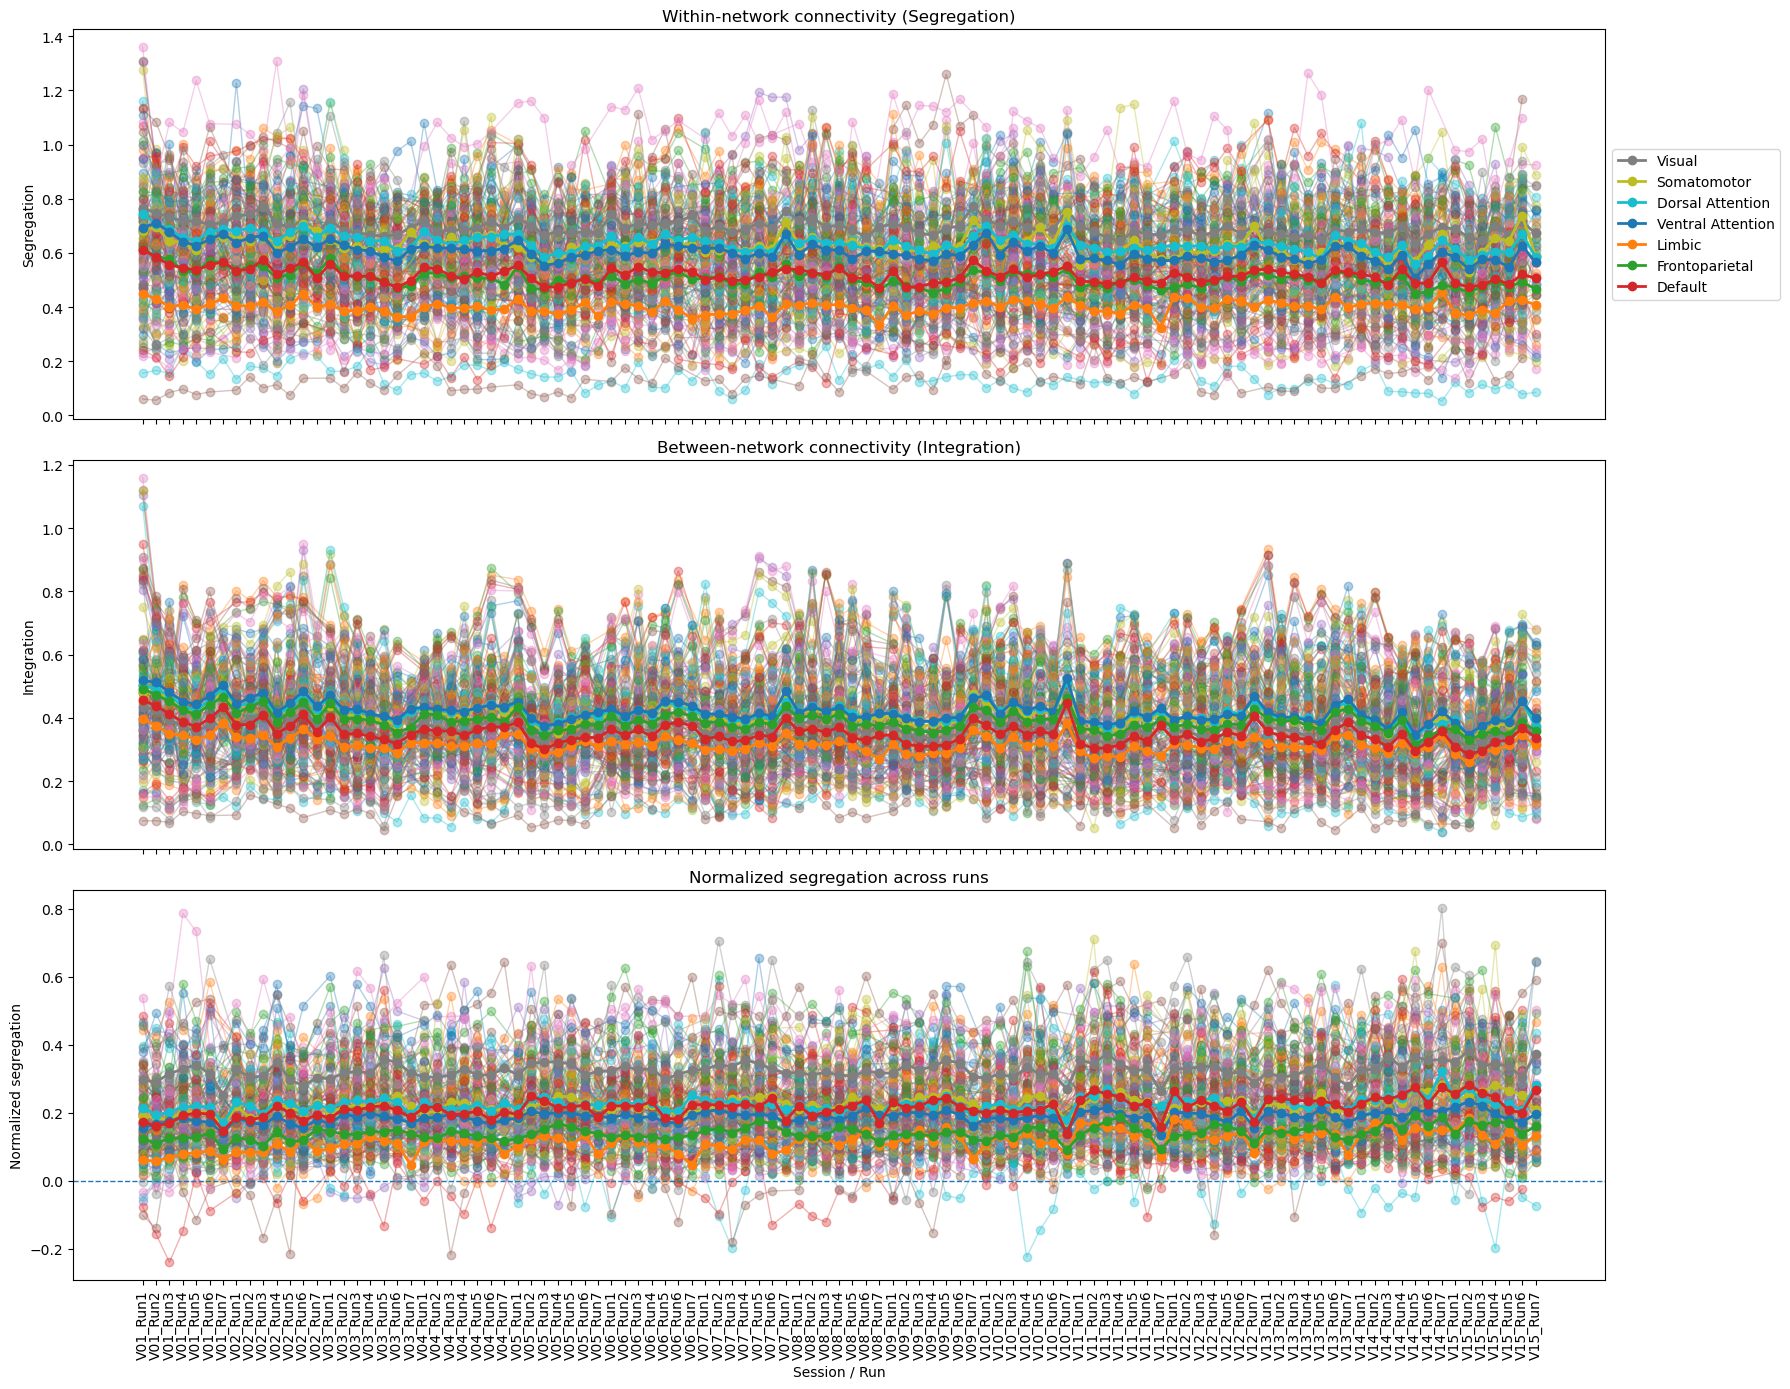

In [7]:
plot_runs_all_subjects(all_data, YEO_NAMES)

### 4b. Group Average Only — All Runs, All Conditions

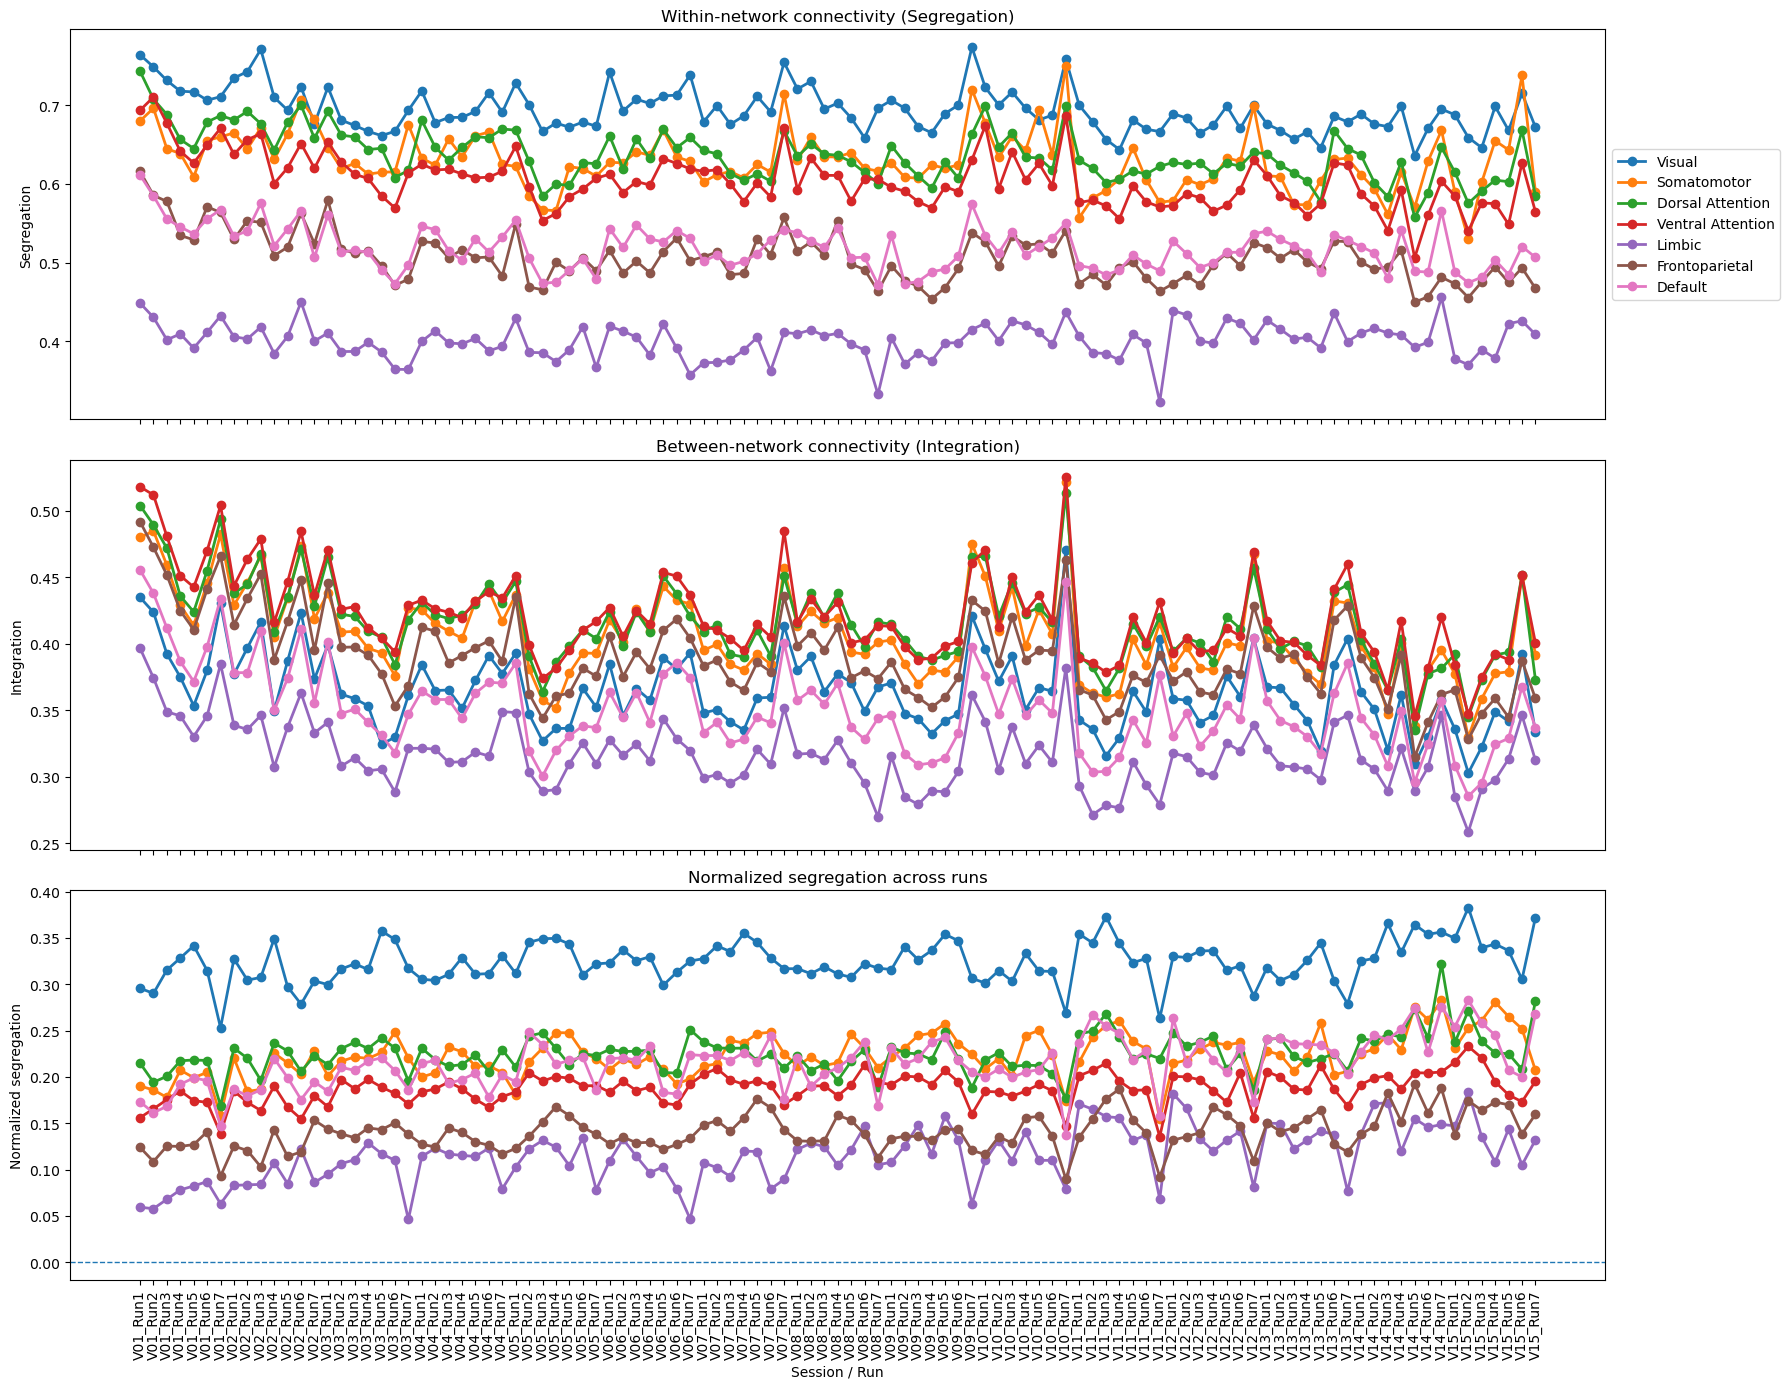

In [8]:
plot_runs_all_subjects(all_data, YEO_NAMES, average_only=True)

### 4c. Group Average Only — All Runs, All Conditions, Transfer, No Feedback

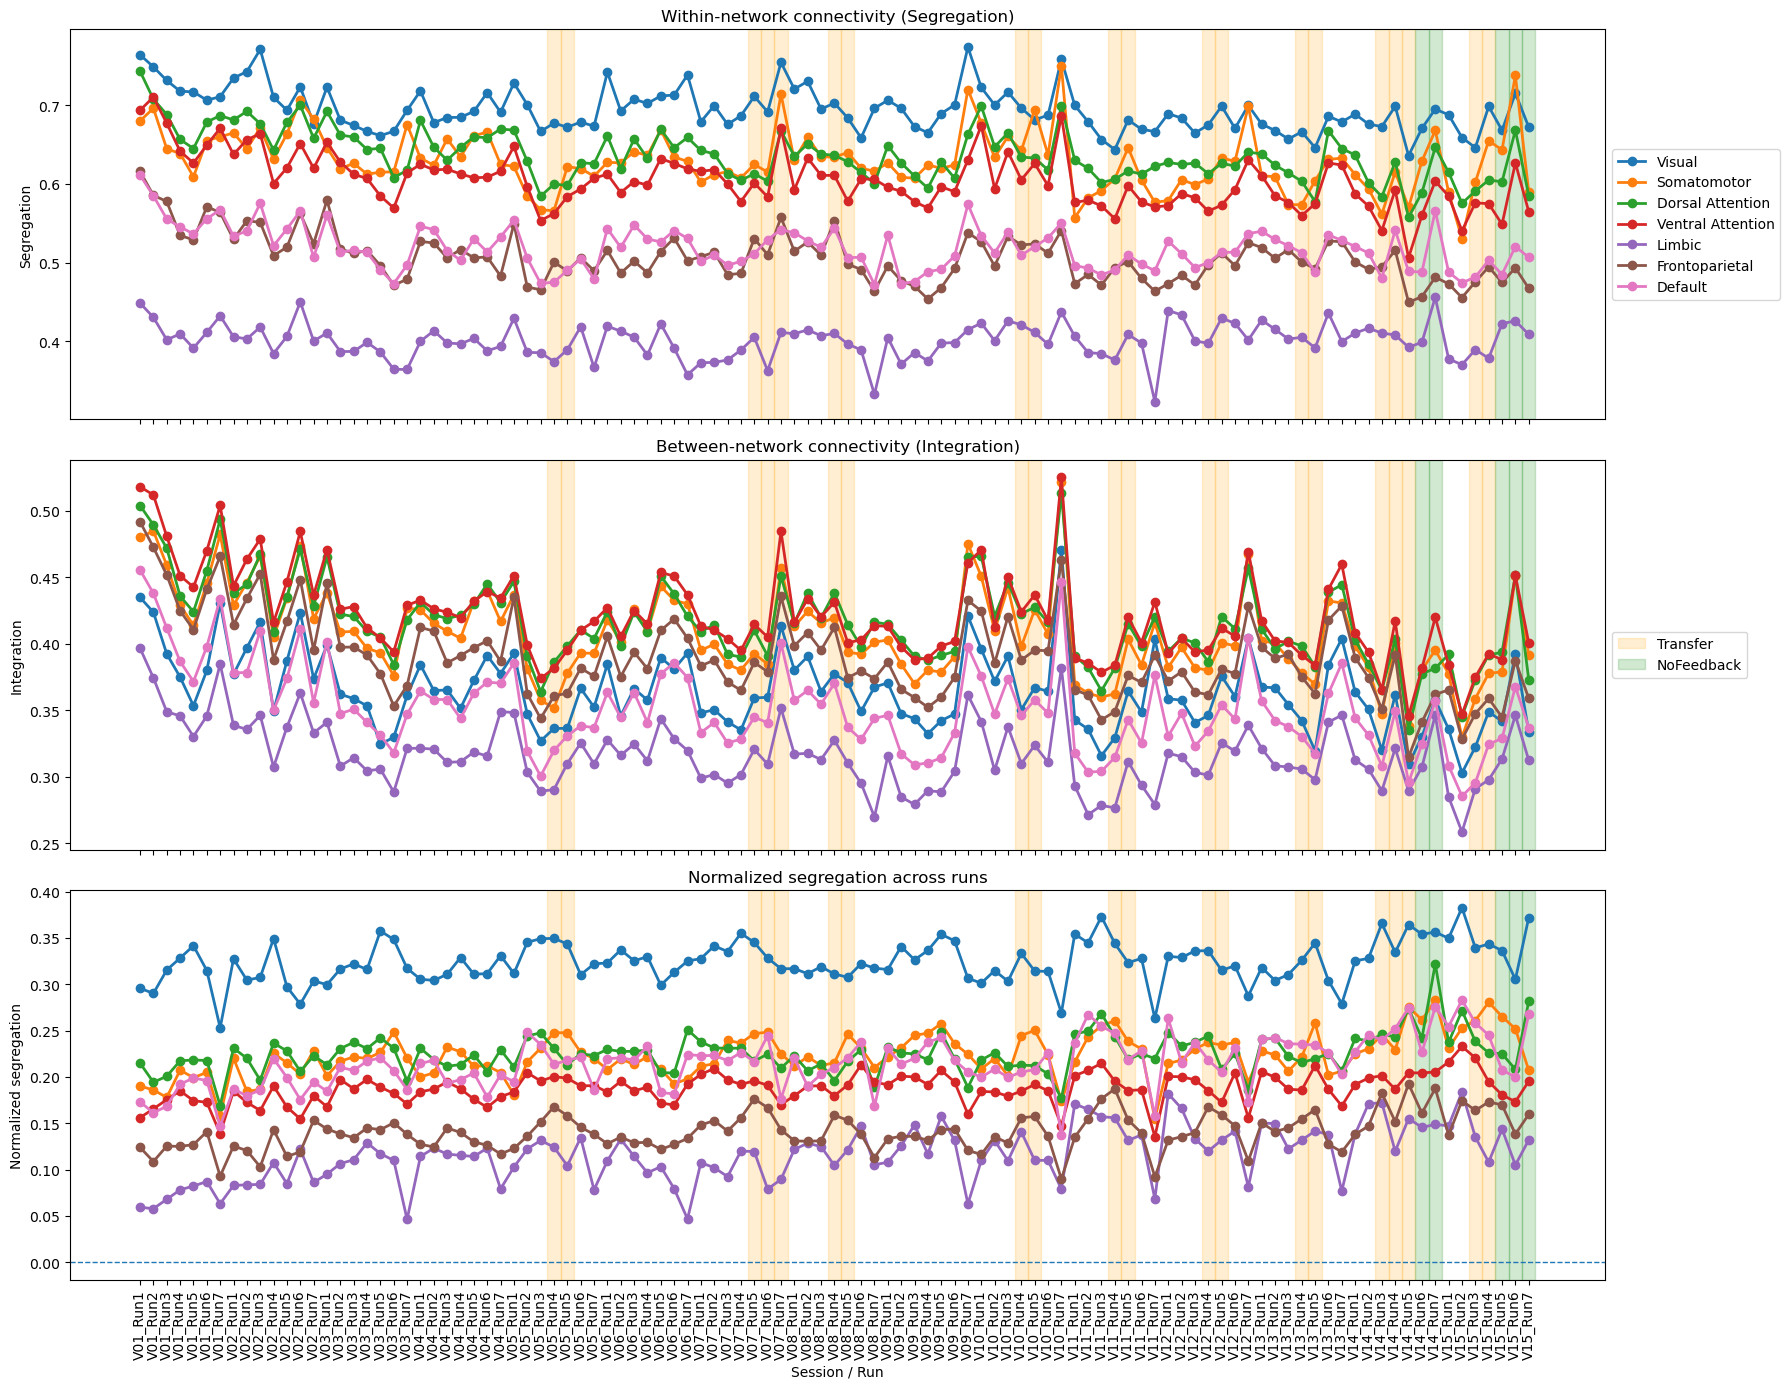

In [9]:
plot_runs_all_subjects(all_data, YEO_NAMES, average_only=True, shade_conditions=True)

## 5. Session Averages — All Conditions

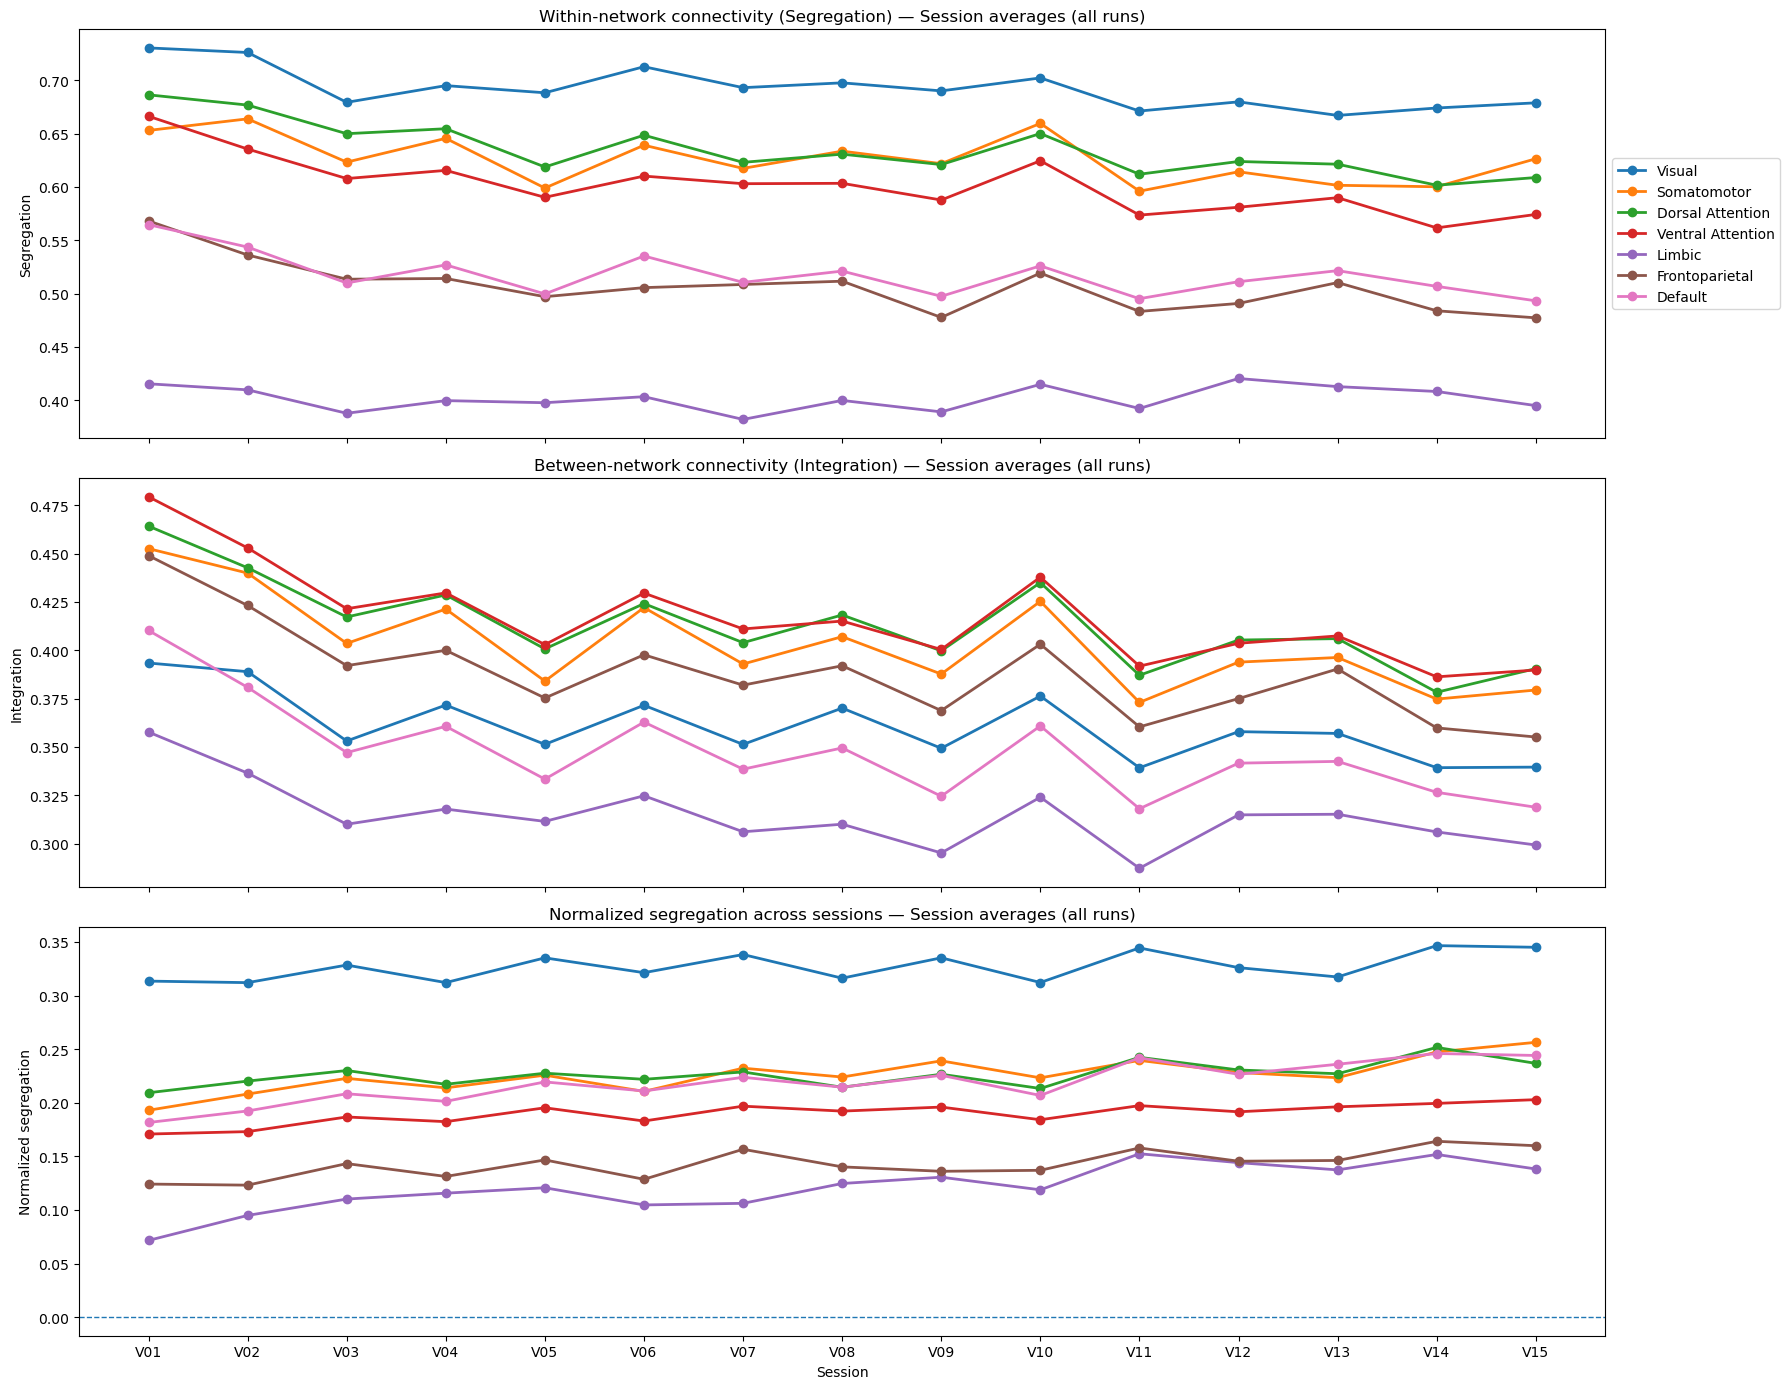

In [10]:
plot_session_averages_all_subjects(all_data, YEO_NAMES, average_only=True)

## 9. Per-Subject Plots
Run the same two plot types for a single subject at a time.  
Change `SUBJECT_ID` to inspect any subject.

--- 003GNV | All runs ---


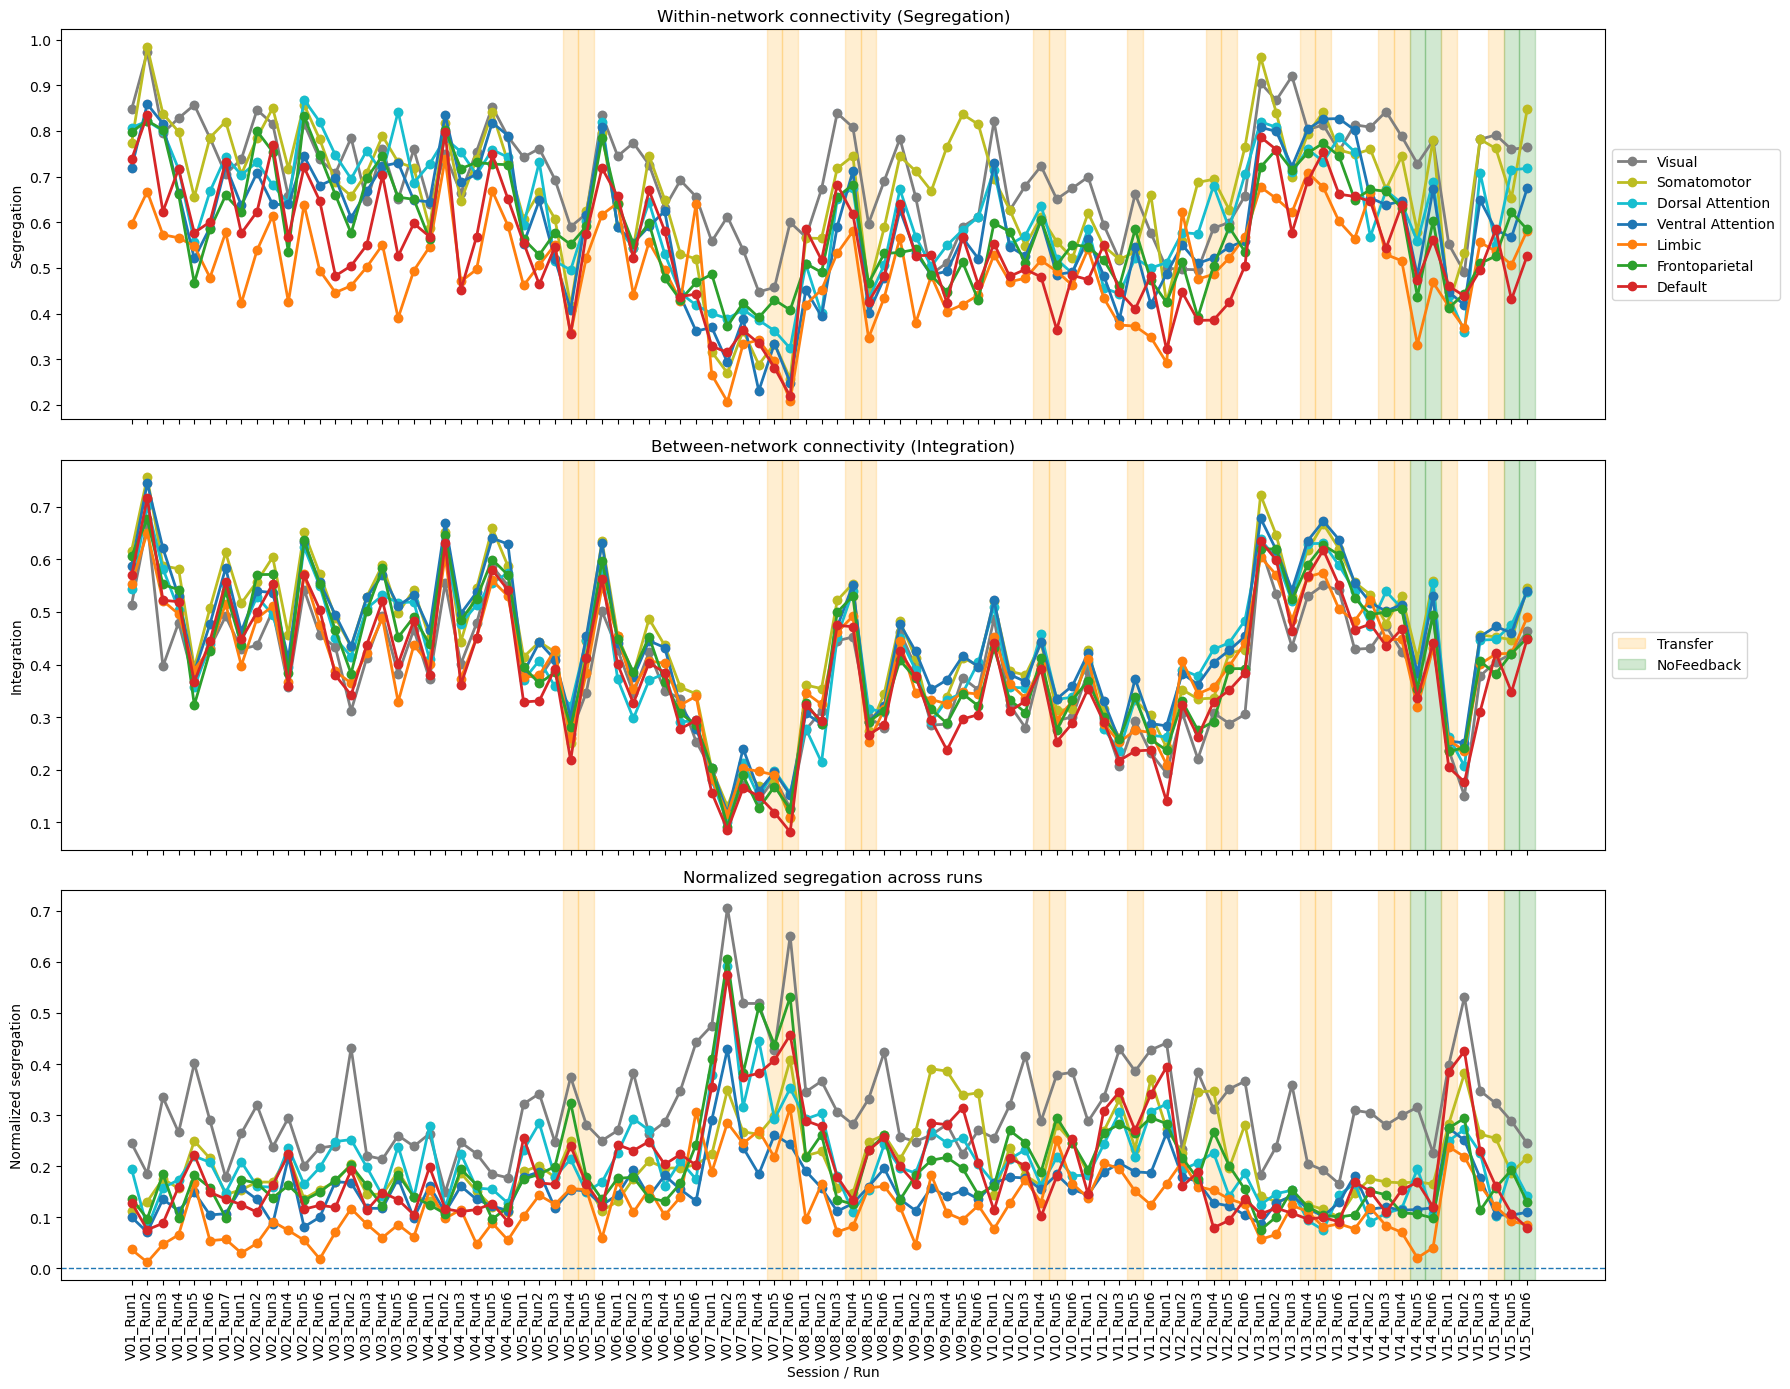

--- 003GNV | Session averages ---


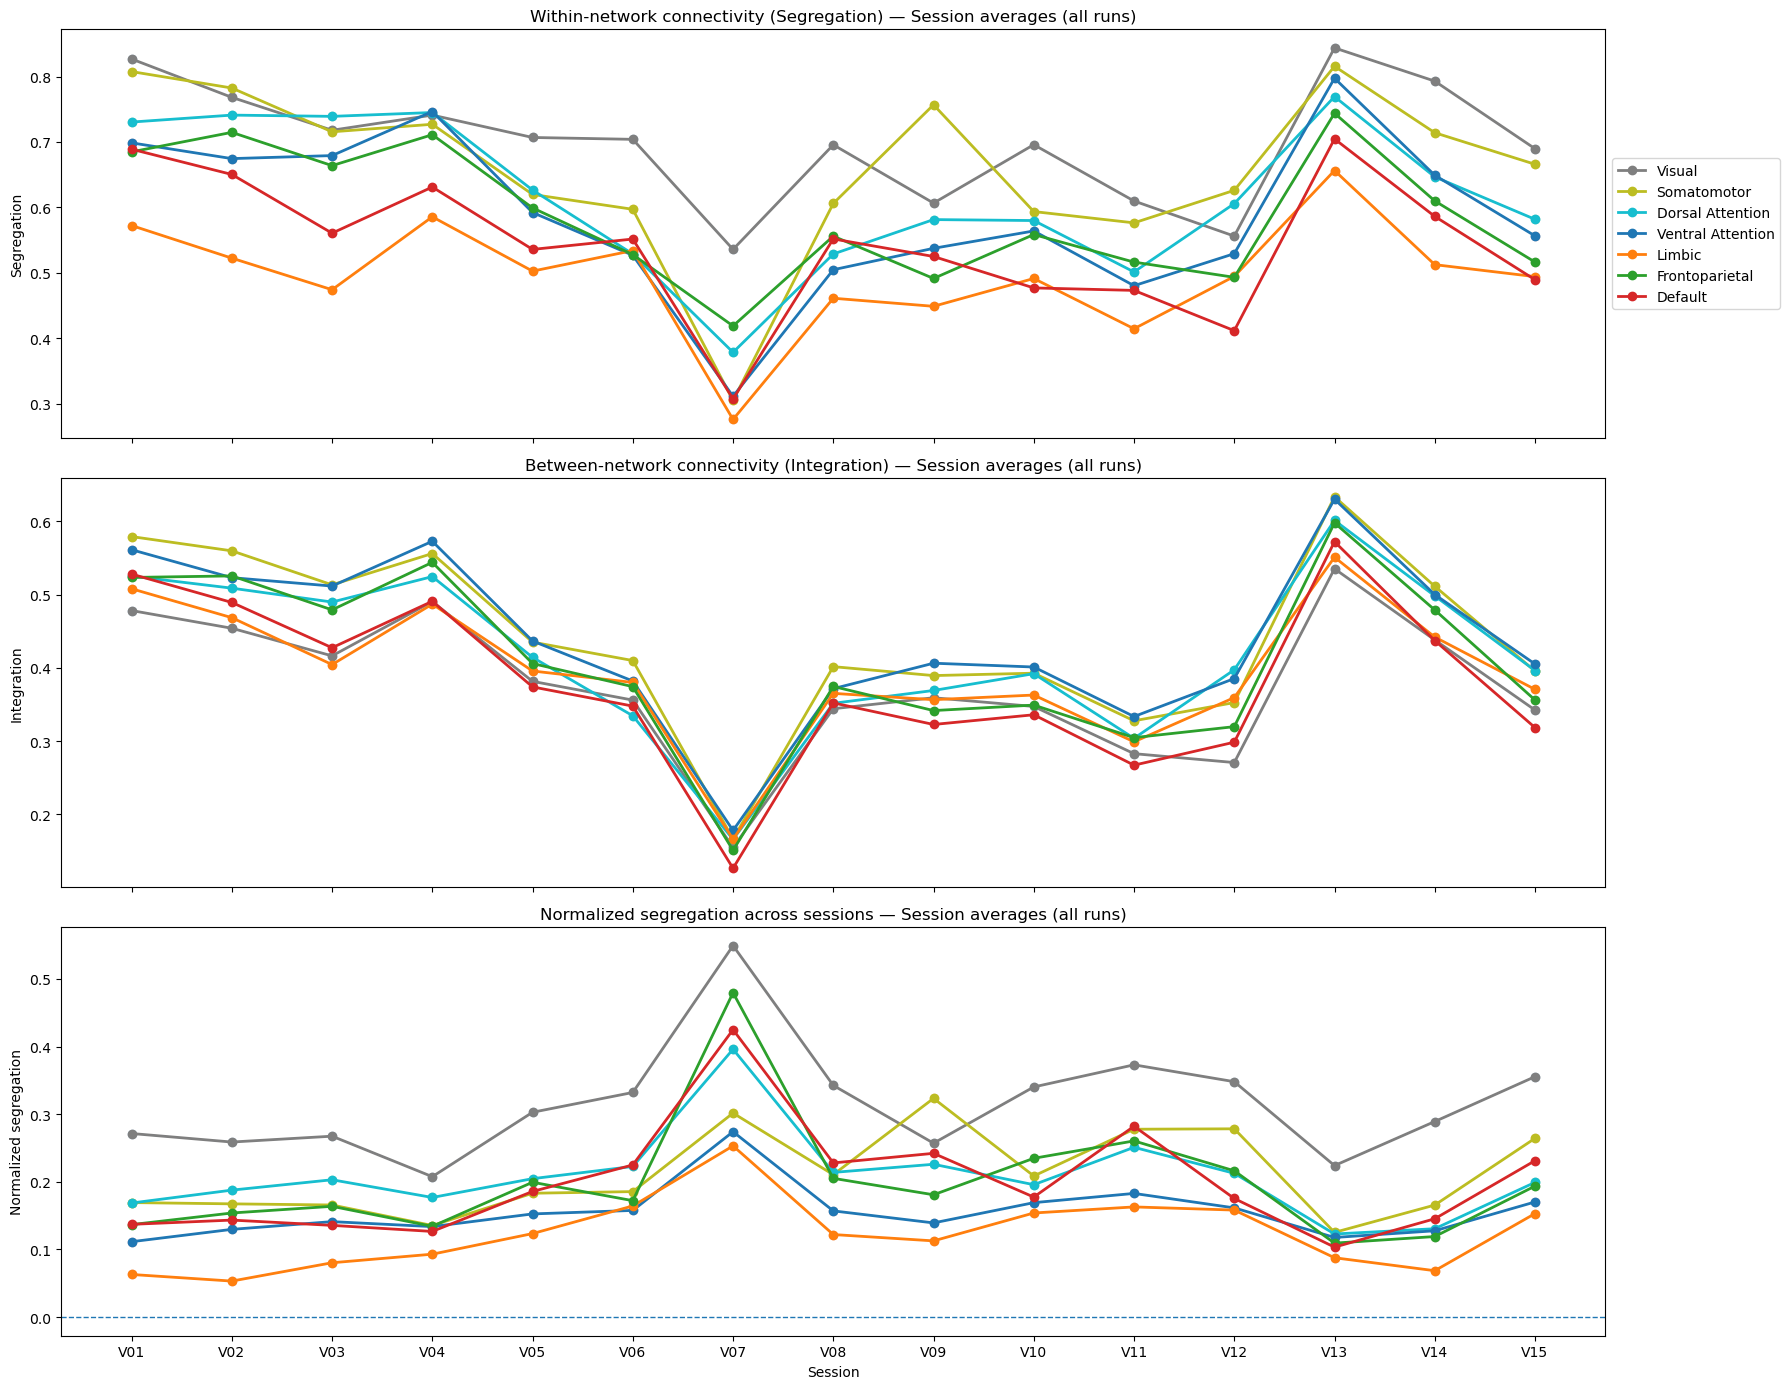

In [11]:
SUBJECT_ID = subject_ids[0]   # change to any subject ID, e.g. "002GNV"

single_subj_data = {SUBJECT_ID: all_data[SUBJECT_ID]}

print(f"--- {SUBJECT_ID} | All runs ---")
plot_runs_all_subjects(single_subj_data, YEO_NAMES,shade_conditions=True)

print(f"--- {SUBJECT_ID} | Session averages ---")
plot_session_averages_all_subjects(single_subj_data, YEO_NAMES)

Plot saved to ../../../Results/Tessnim/figures/seg_int_norm.pdf


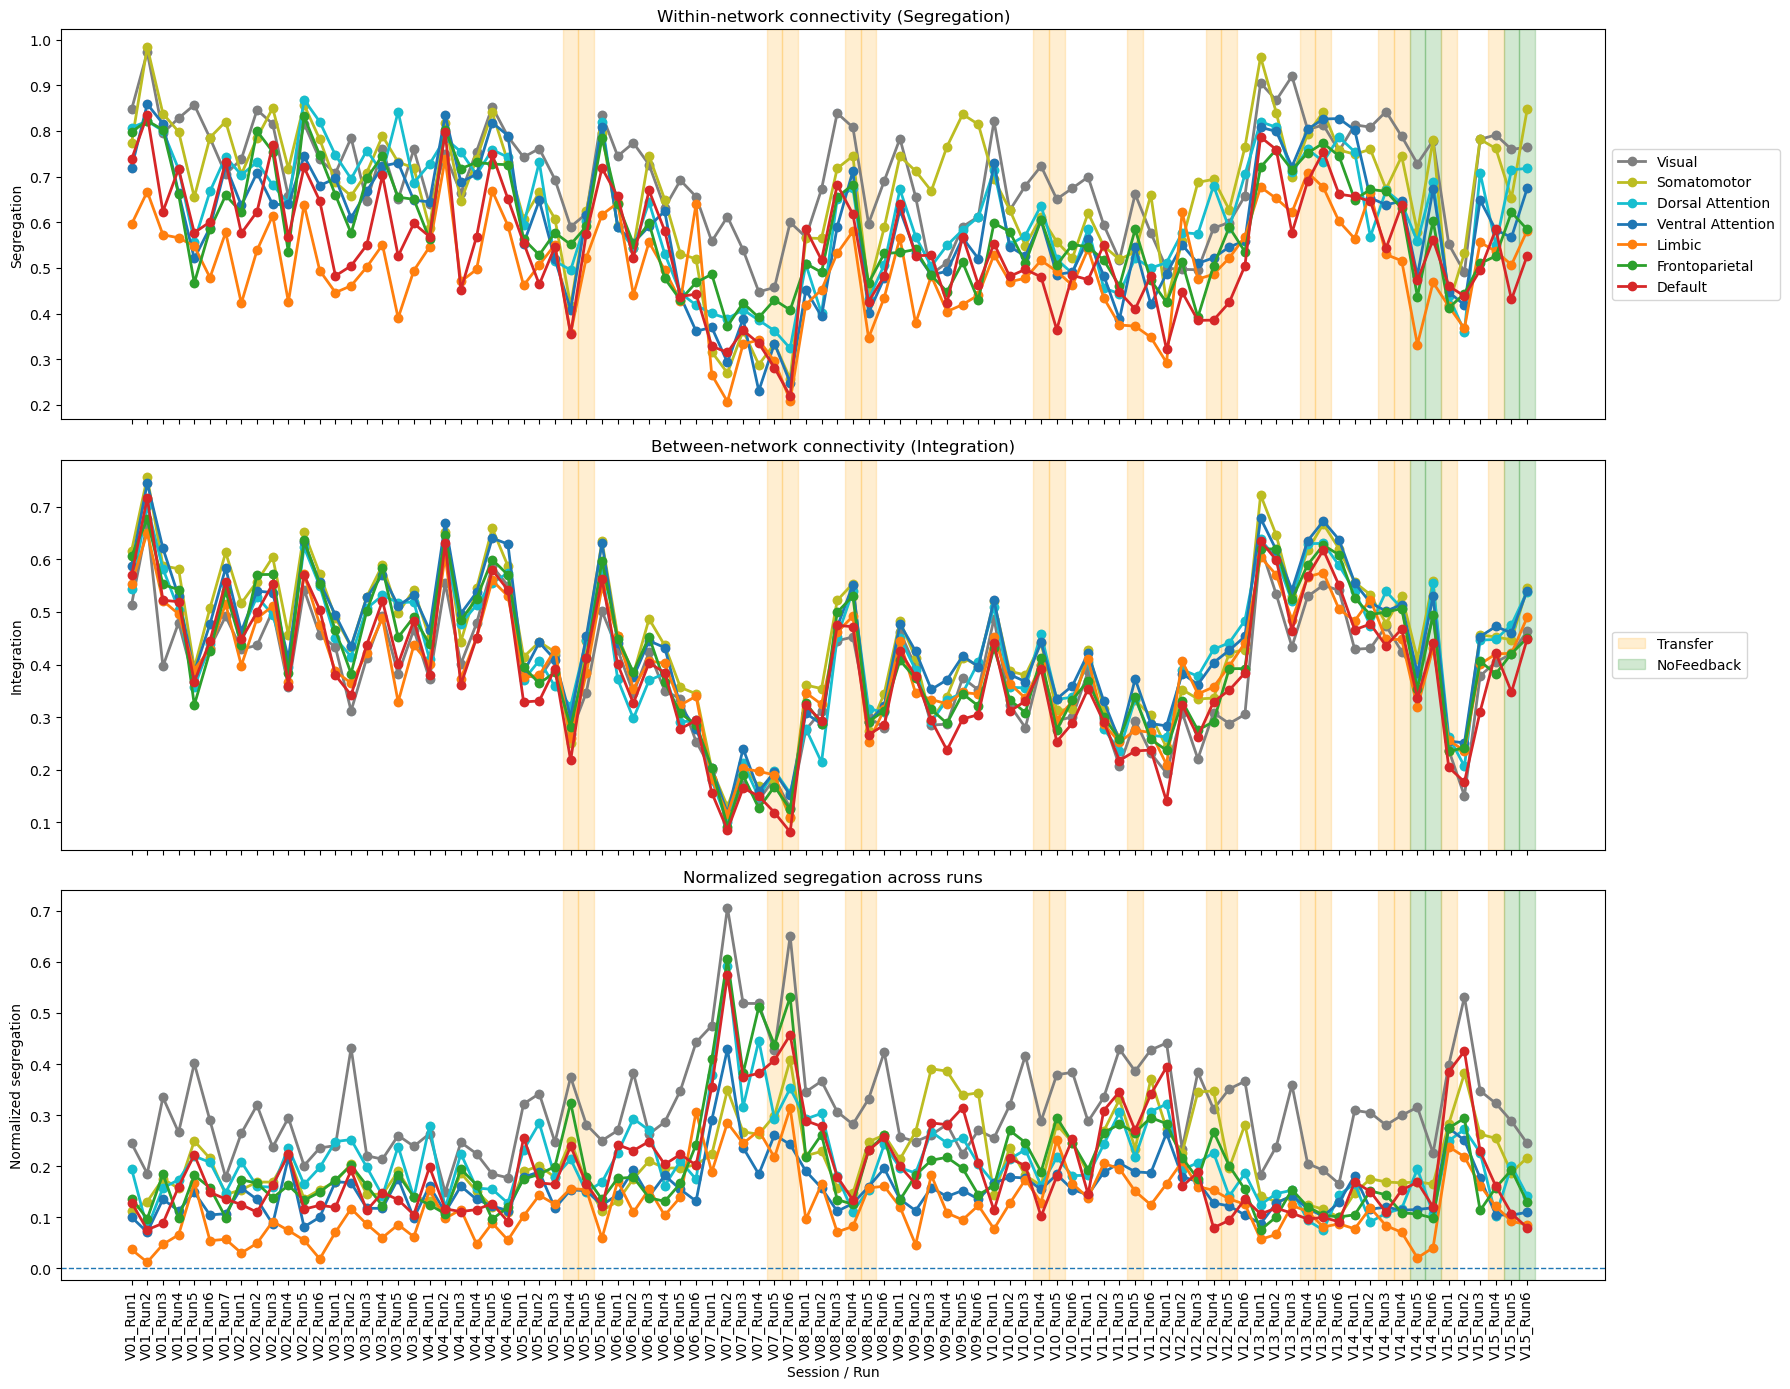

In [14]:
plot_runs_all_subjects(
    single_subj_data,
    YEO_NAMES,
    condition_filter=None,
    average_only=False,
    shade_conditions=True,
    show_subject_counts=False,
    save_path="../../../Results/Tessnim/figures/seg_int_norm.pdf"  # or "plots/seg_int_norm.pdf"
)